In [7]:
# Understanding the Dataset

import pandas as pd

df = pd.read_csv("../data/netflix_stock.csv")

print(df.head())
print(df.columns)
print(df.info())
print(df.describe())




         date       open       high        low      close    volume  \
0  2014-01-02  52.401428  52.511429  51.542858  51.831429  12325600   
1  2014-01-03  52.000000  52.495712  51.842857  51.871429  10817100   
2  2014-01-06  51.889999  52.044285  50.475716  51.367142  15501500   
3  2014-01-07  49.684284  49.698570  48.152859  48.500000  36167600   
4  2014-01-08  48.104286  49.425713  48.074287  48.712856  20001100   

       rsi_7     rsi_14       cci_7      cci_14     sma_50     ema_50  \
0  34.729664  49.183584  -89.573201 -131.288579  50.112828  50.235157   
1  35.587886  49.457208  -65.820581 -103.026189  50.228771  50.299327   
2  29.820674  46.087900 -121.472559 -139.640566  50.312571  50.341203   
3  14.371863  32.522091 -206.762171 -238.029120  50.336228  50.268997   
4  18.049045  34.073549 -117.836707 -180.766801  50.373257  50.207969   

     sma_100    ema_100      macd  bollinger  TrueRange     atr_7    atr_14  \
0  46.385428  46.650698  0.751929  52.607357   1.052857

In [8]:
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)

(2516, 20)
date              0
open              0
high              0
low               0
close             0
volume            0
rsi_7             0
rsi_14            0
cci_7             0
cci_14            0
sma_50            0
ema_50            0
sma_100           0
ema_100           0
macd              0
bollinger         0
TrueRange         0
atr_7             0
atr_14            0
next_day_close    0
dtype: int64
date                  str
open              float64
high              float64
low               float64
close             float64
volume              int64
rsi_7             float64
rsi_14            float64
cci_7             float64
cci_14            float64
sma_50            float64
ema_50            float64
sma_100           float64
ema_100           float64
macd              float64
bollinger         float64
TrueRange         float64
atr_7             float64
atr_14            float64
next_day_close    float64
dtype: object


In [9]:
print(df["date"].head())
print(df["date"].tail())


0    2014-01-02
1    2014-01-03
2    2014-01-06
3    2014-01-07
4    2014-01-08
Name: date, dtype: str
2511    2023-12-22
2512    2023-12-26
2513    2023-12-27
2514    2023-12-28
2515    2023-12-29
Name: date, dtype: str


In [10]:
df["date"] = pd.to_datetime(df["date"])

print(df.dtypes)

date              datetime64[us]
open                     float64
high                     float64
low                      float64
close                    float64
volume                     int64
rsi_7                    float64
rsi_14                   float64
cci_7                    float64
cci_14                   float64
sma_50                   float64
ema_50                   float64
sma_100                  float64
ema_100                  float64
macd                     float64
bollinger                float64
TrueRange                float64
atr_7                    float64
atr_14                   float64
next_day_close           float64
dtype: object


In [11]:
# Correlation Analysis: How strongly is each features related to tomorrow's closing price?

print(df.corr()["next_day_close"].sort_values(ascending=False))

next_day_close    1.000000
close             0.998672
low               0.998424
high              0.998388
open              0.997998
bollinger         0.990971
ema_50            0.982092
sma_50            0.977288
ema_100           0.962769
sma_100           0.949601
atr_14            0.824862
atr_7             0.795081
date              0.789802
TrueRange         0.582236
macd              0.148282
cci_14            0.030702
rsi_14            0.024001
rsi_7             0.021233
cci_7             0.020771
volume           -0.446738
Name: next_day_close, dtype: float64


In [12]:
# Features and Targets creation

X = df.drop(columns=["next_day_close", "date"])
y = df["next_day_close"]

print(X.head())
print(y.head())

        open       high        low      close    volume      rsi_7     rsi_14  \
0  52.401428  52.511429  51.542858  51.831429  12325600  34.729664  49.183584   
1  52.000000  52.495712  51.842857  51.871429  10817100  35.587886  49.457208   
2  51.889999  52.044285  50.475716  51.367142  15501500  29.820674  46.087900   
3  49.684284  49.698570  48.152859  48.500000  36167600  14.371863  32.522091   
4  48.104286  49.425713  48.074287  48.712856  20001100  18.049045  34.073549   

        cci_7      cci_14     sma_50     ema_50    sma_100    ema_100  \
0  -89.573201 -131.288579  50.112828  50.235157  46.385428  46.650698   
1  -65.820581 -103.026189  50.228771  50.299327  46.537571  46.754726   
2 -121.472559 -139.640566  50.312571  50.341203  46.680971  46.846621   
3 -206.762171 -238.029120  50.336228  50.268997  46.791957  46.879558   
4 -117.836707 -180.766801  50.373257  50.207969  46.917071  46.916075   

       macd  bollinger  TrueRange     atr_7    atr_14  
0  0.751929  52.60

In [13]:
# Creating a Random Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)



(2012, 18)
(504, 18)
(2012,)
(504,)


#### At this point we have 2012 training rows, 504 testing rows and 18 input features for both. We have 2012 correct target values for training and 504 correct target values for testing. Our data is now ready for the first model.

## **Linear Regression - Random Split**

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(predictions[:5])
print(y_test.head())

[ 93.9422574  181.13211446 181.11563556 190.60779431 670.54882223]
617      95.440002
927     176.419998
942     181.350006
973     195.080002
1968    662.919983
Name: next_day_close, dtype: float64


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, predictions)

print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R2: ", r2)



MAE:  5.534299026262416
MSE:  74.00261908791052
RMSE:  8.602477497088296
R2:  0.9974192352580904


##### *In random train-test splitting, observations from different time periods are mixed together. As a result, the model may be trained on data from later years while being tested on earlier years, which does not reflect how financial forecasting works in practice. Since stock prices and market conditions are highly dependent on time, the model gains indirect knowledge of patterns across the entire decade. This can lead to overly optimistic performance estimates because the model is evaluated in an environment where information from future periods influences the learning process, making the prediction task easier than it would be in a real-world forecasting scenario.*

## **Linear Regression - Time Based**

In [16]:
# Inspecting the date range

print(df["date"].min())
print(df["date"].max())

# finding the 80% cutoff point now

split_index = int(len(df)*0.8)

print(split_index)
print(df.iloc[split_index]["date"])


2014-01-02 00:00:00
2023-12-29 00:00:00
2012
2021-12-29 00:00:00


In [17]:
# creating new training and testing data using chronological order

X_train_time = X.iloc[:split_index]
X_test_time = X.iloc[split_index:]

y_train_time = y.iloc[:split_index]
y_test_time = y.iloc[split_index:]

print(X_train_time.shape)
print(X_test_time.shape)
print(y_train_time.shape)
print(y_test_time.shape)



(2012, 18)
(504, 18)
(2012,)
(504,)


In [18]:
from sklearn.linear_model import LinearRegression

time_model = LinearRegression()

time_model.fit(X_train_time, y_train_time)

time_predictions = time_model.predict(X_test_time)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_time = mean_absolute_error(y_test_time, time_predictions)
mse_time = mean_squared_error(y_test_time, time_predictions)
rmse_time = mse_time ** 0.5
r2_time = r2_score(y_test_time, time_predictions)

print("MAE:", mae_time)
print("MSE:", mse_time)
print("RMSE:", rmse_time)
print("R2:", r2_time)

MAE: 8.236492332078225
MSE: 164.71410928223705
RMSE: 12.834099472975774
R2: 0.9817274986740481


##### Linear Regression achieved stronger performance under random train-test splitting (MAE = 5.15, RMSE = 8.35, R² = 0.9976) than under chronological time-based validation (MAE = 7.70, RMSE = 12.30, R² = 0.9832). The increase in prediction error suggests that random splitting may provide overly optimistic estimates of model performance by allowing the model to learn patterns from multiple market periods that would not be available in a real forecasting scenario.

### **Decision Tree - Random**

In [20]:
# importing decision tree

from sklearn.tree import DecisionTreeRegressor

dt_random = DecisionTreeRegressor(random_state=42)

dt_random.fit(X_train, y_train)

dt_random_predictions = dt_random.predict(X_test)

In [21]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_dt_random = mean_absolute_error(y_test, dt_random_predictions)
mse_dt_random = mean_squared_error(y_test, dt_random_predictions)
rmse_dt_random = mse_dt_random ** 0.5
r2_dt_random = r2_score(y_test, dt_random_predictions)

print("MAE:", mae_dt_random)
print("RMSE:", rmse_dt_random)
print("R2:", r2_dt_random)


MAE: 7.829447285714284
RMSE: 12.767838034677238
R2: 0.9943149268648983


### **Decision Tree - Time Based**

In [22]:
from sklearn.tree import DecisionTreeRegressor

dt_time = DecisionTreeRegressor(random_state=42)
dt_time.fit(X_train_time, y_train_time)

dt_time_predictions = dt_time.predict(X_test_time)

In [23]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_dt_time = mean_absolute_error(y_test_time, dt_time_predictions)
mse_dt_time = mean_squared_error(y_test_time, dt_time_predictions)
rmse_dt_time = mse_dt_time ** 0.5
r2_dt_time = r2_score(y_test_time, dt_time_predictions)

print("MAE:", mae_dt_time)
print("RMSE:", rmse_dt_time)
print("R2:", r2_dt_time)

MAE: 21.581943428571428
RMSE: 29.230835798083728
R2: 0.9052128060725255


#### At this point the data is suggesting that:

##### More flexible models may benefit more from random validation and suffer larger performance degradation under realistic time-based validation.

### **Random Forest - Random**

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_random = RandomForestRegressor(n_estimators=100, random_state=42)

rf_random.fit(X_train, y_train)

rf_random_predictions = rf_random.predict(X_test)

In [25]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf_random = mean_absolute_error(y_test, rf_random_predictions)
mse_rf_random  = mean_squared_error(y_test, rf_random_predictions)
rmse_rf_random = mse_rf_random ** 0.5
r2_rf_random = r2_score(y_test, rf_random_predictions)

print("MAE:", mae_rf_random)
print("RMSE:", rmse_rf_random)
print("R2:", r2_rf_random)

MAE: 5.687754731349196
RMSE: 9.127067613380571
R2: 0.9970948814335441


### **Random Forest - Time Based**

In [26]:
rf_time = RandomForestRegressor(n_estimators = 100, random_state = 42)

rf_time.fit(X_train_time, y_train_time)

rf_time_predictions = rf_time.predict(X_test_time)

In [27]:
# Evaluation

mae_rf_time = mean_absolute_error(y_test_time, rf_time_predictions)
mse_rf_time = mean_squared_error(y_test_time, rf_time_predictions)
rmse_rf_time = mse_rf_time ** 0.5
r2_rf_time = r2_score(y_test_time, rf_time_predictions)

print("MAE:", mae_rf_time)
print("RMSE:", rmse_rf_time)
print("R2:", r2_rf_time)


MAE: 12.16674639480157
RMSE: 16.810641416178125
R2: 0.9686501282270422


## **Walk-Forward Validation or Expanding Window Validation**

In [28]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    print("TRAIN:", len(train_index))
    print("TEST:", len(test_index))
    print("----------------------")

TRAIN: 421
TEST: 419
----------------------
TRAIN: 840
TEST: 419
----------------------
TRAIN: 1259
TEST: 419
----------------------
TRAIN: 1678
TEST: 419
----------------------
TRAIN: 2097
TEST: 419
----------------------


#### **Linear Regression - Walk-Forward Validation**

In [29]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

for train_index, test_index in tscv.split(X):
    
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]
    
    model = LinearRegression()
    model.fit(X_train_fold, y_train_fold)
    
    predictions_lr_wf = model.predict(X_test_fold)
    
    mae_scores.append(mean_absolute_error(y_test_fold, predictions_lr_wf))
    
    rmse_lr_wf = mean_squared_error(
    y_test_fold,
    predictions_lr_wf
    ) ** 0.5

    print("Fold RMSE:", rmse_lr_wf)
    rmse_scores.append(rmse_lr_wf)
    
    r2_scores.append(r2_score(y_test_fold, predictions_lr_wf))
lr_fold_rmse = rmse_scores.copy()
mean_rmse_lr_wf = np.mean(rmse_scores)
print("Average MAE:", np.mean(mae_scores))
print("Average RMSE:", mean_rmse_lr_wf)
print("Average R2:", np.mean(r2_scores))


Fold RMSE: 6.381539452474451
Fold RMSE: 10.189660346688086
Fold RMSE: 10.37393892189178
Fold RMSE: 15.093506520971392
Fold RMSE: 9.266048691929312
Average MAE: 7.333539607160463
Average RMSE: 10.260938786791005
Average R2: 0.9607762717240853


#### **Decision Tree - Walk-Forward Validation**

In [30]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []
fold = 1
for train_index, test_index in tscv.split(X):
    
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    model = DecisionTreeRegressor(random_state=42)
    
    model.fit(X_train_fold, y_train_fold)
    
    predictions_dt_wf = model.predict(X_test_fold)
    
    mae_scores.append(
        mean_absolute_error(y_test_fold, predictions_dt_wf)
    )
    
    rmse_dt_wf = mean_squared_error(
        y_test_fold,
        predictions_dt_wf
    ) ** 0.5

    rmse_scores.append(rmse_dt_wf)
    print(f"Fold {fold} RMSE:", rmse_dt_wf)

    fold += 1
    
    r2_scores.append(
        r2_score(y_test_fold, predictions_dt_wf)
    )
dt_fold_rmse = rmse_scores.copy()
mean_rmse_dt_wf = np.mean(rmse_scores)
print("Average MAE:", np.mean(mae_scores))
print("Average RMSE:", mean_rmse_dt_wf)
print("Average R2:", np.mean(r2_scores))

Fold 1 RMSE: 12.79780341542204
Fold 2 RMSE: 133.53780454188234
Fold 3 RMSE: 48.05499275635329
Fold 4 RMSE: 59.95018794620788
Fold 5 RMSE: 15.359711992339793
Average MAE: 40.62763941622911
Average RMSE: 53.94010013044107
Average R2: 0.13826235553526803


#### **Random Forest - Walk-Forward Validation**

In [31]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits = 5)

mae_scores = []
rmse_scores = []
r2_scores = []

for train_index, test_index in tscv.split(X):
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_fold, y_train_fold)
    
    predictions_rf_wf = model.predict(X_test_fold)
    
    mae_scores.append(
        mean_absolute_error(y_test_fold, predictions_rf_wf)
        )
    rmse_rf_wf = mean_squared_error(
    y_test_fold,
    predictions_rf_wf
    ) ** 0.5

    rmse_scores.append(rmse_rf_wf)

    print("Fold RMSE:", rmse_rf_wf)
    
    r2_scores.append(
        r2_score(y_test_fold, predictions_rf_wf)
    )
rf_fold_rmse = rmse_scores.copy()
mean_rmse_rf_wf =  np.mean(rmse_scores)  
print("Average MAE:", np.mean(mae_scores))
print("Average RMSE:", mean_rmse_rf_wf)
print("Average R2:", np.mean(r2_scores))
    
    

Fold RMSE: 13.468279288286272
Fold RMSE: 133.31579337746786
Fold RMSE: 36.94990442940696
Fold RMSE: 48.925502775199554
Fold RMSE: 10.619845444035942
Average MAE: 36.23706124287831
Average RMSE: 48.65586506287932
Average R2: 0.20851674633711292


In [32]:
tscv = TimeSeriesSplit(n_splits = 5)

fold = 1

for train_index, test_index in tscv.split(X):
    train_start = df.iloc[train_index[0]]["date"]
    train_end = df.iloc[train_index[-1]]["date"]
    
    test_start = df.iloc[test_index[0]]["date"]
    test_end = df.iloc[test_index[-1]]["date"]
    
    print(f"Fold {fold}")
    print("Train:", train_start, "to", train_end)
    print("Test :", test_start, "to", test_end)
    print("---------------------")

    fold += 1


Fold 1
Train: 2014-01-02 00:00:00 to 2015-09-02 00:00:00
Test : 2015-09-03 00:00:00 to 2017-05-03 00:00:00
---------------------
Fold 2
Train: 2014-01-02 00:00:00 to 2017-05-03 00:00:00
Test : 2017-05-04 00:00:00 to 2019-01-02 00:00:00
---------------------
Fold 3
Train: 2014-01-02 00:00:00 to 2019-01-02 00:00:00
Test : 2019-01-03 00:00:00 to 2020-08-31 00:00:00
---------------------
Fold 4
Train: 2014-01-02 00:00:00 to 2020-08-31 00:00:00
Test : 2020-09-01 00:00:00 to 2022-04-29 00:00:00
---------------------
Fold 5
Train: 2014-01-02 00:00:00 to 2022-04-29 00:00:00
Test : 2022-05-02 00:00:00 to 2023-12-29 00:00:00
---------------------


###### *Fold-level analysis revealed substantial variation in model performance across different market periods. The largest prediction errors occurred during the May 2017 to January 2019 testing period, where both Decision Tree and Random Forest models produced RMSE values exceeding 133, while Linear Regression maintained an RMSE of only 7.51. This suggests that tree-based models struggled to generalize during periods of rapid stock appreciation and changing market conditions. In contrast, Linear Regression demonstrated relatively stable performance across all folds, indicating greater robustness under walk-forward validation.*

### **Visualization**

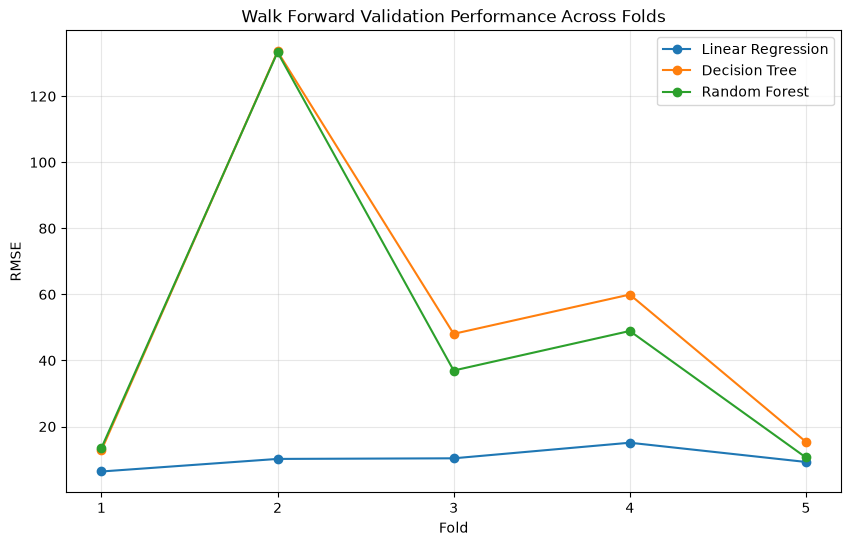

In [33]:
import matplotlib.pyplot as plt

folds = [1,2,3,4,5]

plt.figure(figsize=(10,6))

plt.plot(folds, lr_fold_rmse, marker = "o", label="Linear Regression")
plt.plot(folds, dt_fold_rmse, marker="o", label="Decision Tree")
plt.plot(folds, rf_fold_rmse, marker= "o", label="Random Forest")

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.xticks([1,2,3,4,5])
plt.grid(True, alpha = 0.3)
plt.title("Walk Forward Validation Performance Across Folds")
plt.legend()

plt.show()

#### **XGBOOST - Random Split**

In [34]:
import sys
!{sys.executable} -m pip install xgboost

'c:\Users\Dell\OneDrive\Desktop\Research' is not recognized as an internal or external command,
operable program or batch file.


In [35]:
from xgboost import  XGBRegressor

xgb_random = XGBRegressor(n_estimators = 100, random_state = 42)

xgb_random.fit(X_train, y_train)

xgb_random_predictions = xgb_random.predict(X_test)

print(type(xgb_random))
print(xgb_random_predictions[:5])



<class 'xgboost.sklearn.XGBRegressor'>
[ 93.85923 180.97826 176.91286 191.10123 674.74634]


In [36]:
#Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_xgb_random = mean_absolute_error(y_test, xgb_random_predictions)
mse_xgb_random = mean_squared_error(y_test, xgb_random_predictions)
rmse_xgb_random = mse_xgb_random**0.5

r2_xgb_random = r2_score(y_test, xgb_random_predictions)

print("MAE:", mae_xgb_random)
print("RMSE:", rmse_xgb_random)
print("R2:", r2_xgb_random)

MAE: 6.066817635286361
RMSE: 9.42381457787306
R2: 0.9969029031170712


#### **XGBOOST - Time Based Split**

In [37]:
from xgboost import  XGBRegressor

xgb_time = XGBRegressor(n_estimators = 100, random_state = 42)

xgb_time.fit(X_train_time, y_train_time)

xgb_time_predictions = xgb_time.predict(X_test_time)

print(type(xgb_time))
print(xgb_time_predictions[:5])


<class 'xgboost.sklearn.XGBRegressor'>
[595.0727  611.58167 596.6984  602.3565  596.04456]


In [38]:
mae_xgb_time = mean_absolute_error(y_test_time, xgb_time_predictions)
mse_xgb_time = mean_squared_error(y_test_time, xgb_time_predictions)
rmse_xgb_time = mse_xgb_time**0.5

r2_xgb_time = r2_score(y_test_time, xgb_time_predictions)

print("MAE:", mae_xgb_time)
print("RMSE:", rmse_xgb_time)
print("R2:", r2_xgb_time)


MAE: 16.23566652068026
RMSE: 23.06693917798608
R2: 0.940973485232993


#### **XGBoost - Walk Forward Validation**

In [39]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits = 5)

mae_scores = []
rmse_scores = []
r2_scores = []

for train_index, test_index in tscv.split(X):
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]
    
    model = XGBRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_fold, y_train_fold)
    
    predictions_xgb_wf = model.predict(X_test_fold)
    
    mae_scores.append(
        mean_absolute_error(y_test_fold, predictions_xgb_wf)
        )
    rmse_xgb_wf = mean_squared_error(
    y_test_fold,
    predictions_xgb_wf
    ) ** 0.5

    rmse_scores.append(rmse_xgb_wf)

    print("Fold RMSE:", rmse_xgb_wf)
    
    r2_scores.append(
        r2_score(y_test_fold, predictions_xgb_wf)
    )
xgb_fold_rmse = rmse_scores.copy()
mean_rmse_xgb_wf =  np.mean(rmse_scores)  
print("Average MAE:", np.mean(mae_scores))
print("Average RMSE:", mean_rmse_xgb_wf)
print("Average R2:", np.mean(r2_scores))
    
    

Fold RMSE: 16.518285062644253
Fold RMSE: 134.14840701770942
Fold RMSE: 44.27270842371126
Fold RMSE: 52.700060541989544
Fold RMSE: 12.187786576597123
Average MAE: 38.00253083409672
Average RMSE: 51.96544952453032
Average R2: 0.11063840630868868


#### **Neural Network (MLP) - Random**

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
from sklearn.neural_network import MLPRegressor

mlp_random = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

mlp_random.fit(X_train_scaled, y_train)

mlp_random_predictions = mlp_random.predict(X_test_scaled)

print(type(mlp_random))
print(mlp_random_predictions[:5])

<class 'sklearn.neural_network._multilayer_perceptron.MLPRegressor'>
[ 94.88673604 177.96746638 182.36917537 188.9610337  670.07323006]


In [42]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_mlp_random = mean_absolute_error(
    y_test,
    mlp_random_predictions
)

mse_mlp_random = mean_squared_error(
    y_test,
    mlp_random_predictions
)

rmse_mlp_random = mse_mlp_random ** 0.5

r2_mlp_random = r2_score(
    y_test,
    mlp_random_predictions
)

print("MAE:", mae_mlp_random)
print("RMSE:", rmse_mlp_random)
print("R2:", r2_mlp_random)

MAE: 5.973059113271069
RMSE: 9.11941104783569
R2: 0.9970997535133617


###### *Initial MLP experiments produced extremely poor results(RMSE ≈ 384) when trained on unscaled features. After applying StandardScaler, RMSE improved to ≈ 9.12, demonstrating the sensitivity of neural networks to feature scaling.*

#### **Neural Network (MLP) - Time Based**

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_time_scaled = scaler.fit_transform(X_train_time)
X_test_time_scaled = scaler.transform(X_test_time)



In [44]:
from sklearn.neural_network import MLPRegressor

mlp_time = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

mlp_time.fit(X_train_time_scaled, y_train_time)

mlp_time_predictions = mlp_time.predict(X_test_time_scaled)
print(mlp_time_predictions[:5])

[615.73922264 617.80602193 605.06879784 597.2031522  591.32513604]


In [45]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_mlp_time = mean_absolute_error(
    y_test_time,
    mlp_time_predictions
)

mse_mlp_time = mean_squared_error(
    y_test_time,
    mlp_time_predictions
)

rmse_mlp_time = mse_mlp_time ** 0.5

r2_mlp_time = r2_score(
    y_test_time,
    mlp_time_predictions
)

print("MAE:", mae_mlp_time)
print("RMSE:", rmse_mlp_time)
print("R2:", r2_mlp_time)

MAE: 16.01783194910818
RMSE: 30.57533132063523
R2: 0.8962926484144794


#### **MLP - Walk Forward Validation**

In [46]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits = 5)

mae_scores = []
rmse_scores = []
r2_scores = []

for train_index, test_index in tscv.split(X):
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    
    scaler = StandardScaler()
    
    X_train_fold_scaled = scaler.fit_transform(X_train_fold)
    X_test_fold_scaled = scaler.transform(X_test_fold)
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]
    
    model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state = 42)
    model.fit(X_train_fold_scaled, y_train_fold)
    
    predictions_mlp_wf = model.predict(X_test_fold_scaled)
    
    mae_scores.append(
        mean_absolute_error(y_test_fold, predictions_mlp_wf)
        )
    rmse_mlp_wf = mean_squared_error(
    y_test_fold,
    predictions_mlp_wf
    ) ** 0.5

    rmse_scores.append(rmse_mlp_wf)

    print("Fold RMSE:", rmse_mlp_wf)
    
    r2_scores.append(
        r2_score(y_test_fold, predictions_mlp_wf)
    )
mlp_fold_rmse = rmse_scores.copy()
mean_rmse_mlp_wf =  np.mean(rmse_scores)  
print("Average MAE:", np.mean(mae_scores))
print("Average RMSE:", mean_rmse_mlp_wf)
print("Average R2:", np.mean(r2_scores))
    
    

c:\Users\Dell\OneDrive\Desktop\Research Project\tf-env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold RMSE: 26.281802558129964


c:\Users\Dell\OneDrive\Desktop\Research Project\tf-env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold RMSE: 50.756061617804846


c:\Users\Dell\OneDrive\Desktop\Research Project\tf-env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold RMSE: 13.744666776396636
Fold RMSE: 25.619568462923926
Fold RMSE: 14.097680854302027
Average MAE: 18.191350223038135
Average RMSE: 26.099956053911477
Average R2: 0.49773838340657584


### **Visualization**

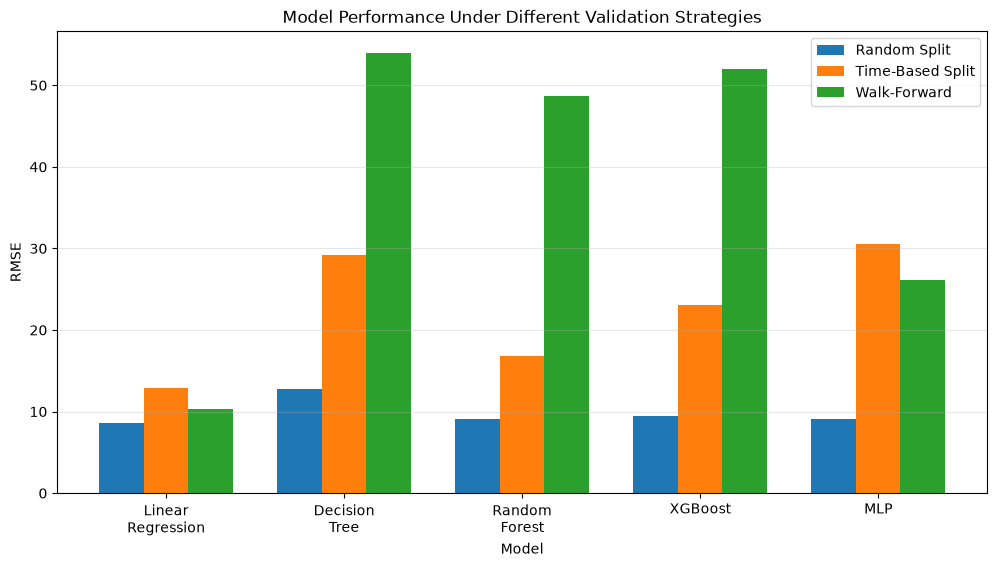

In [47]:
import matplotlib.pyplot as plt

models = [
    "Linear\nRegression",
    "Decision\nTree",
    "Random\nForest",
    "XGBoost",
    "MLP"
]

random_rmse = [
    rmse,
    rmse_dt_random,
    rmse_rf_random,
    rmse_xgb_random,
    rmse_mlp_random
]

time_rmse = [
    rmse_time,
    rmse_dt_time,
    rmse_rf_time,
    rmse_xgb_time,
    rmse_mlp_time
]

walk_rmse = [
    mean_rmse_lr_wf,
    mean_rmse_dt_wf,
    mean_rmse_rf_wf,
    mean_rmse_xgb_wf,
    mean_rmse_mlp_wf
]

x = range(len(models))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(
    [i-width for i in x],
    random_rmse,
    width=width,
    label="Random Split"
)

plt.bar(
    x,
    time_rmse,
    width=width,
    label="Time-Based Split"
)

plt.bar(
    [i+width for i in x],
    walk_rmse,
    width=width,
    label="Walk-Forward"
)

plt.xticks(x, models)
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Model Performance Under Different Validation Strategies")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

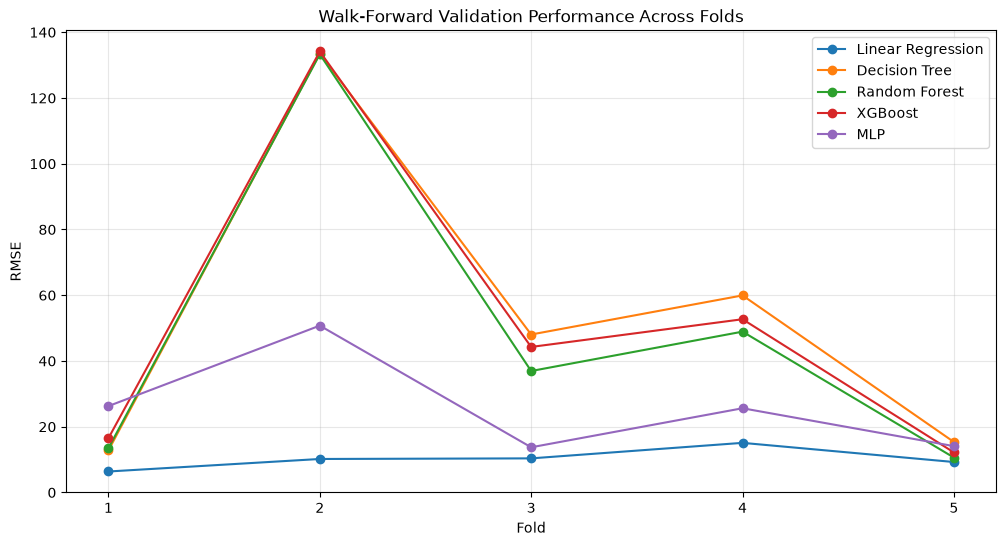

In [48]:
import matplotlib.pyplot as plt

folds = [1,2,3,4,5]

plt.figure(figsize=(12,6))

plt.plot(
    folds,
    lr_fold_rmse,
    marker="o",
    label="Linear Regression"
)

plt.plot(
    folds,
    dt_fold_rmse,
    marker="o",
    label="Decision Tree"
)

plt.plot(
    folds,
    rf_fold_rmse,
    marker="o",
    label="Random Forest"
)

plt.plot(
    folds,
    xgb_fold_rmse,
    marker="o",
    label="XGBoost"
)

plt.plot(
    folds,
    mlp_fold_rmse,
    marker="o",
    label="MLP"
)

plt.xticks([1,2,3,4,5])
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("Walk-Forward Validation Performance Across Folds")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

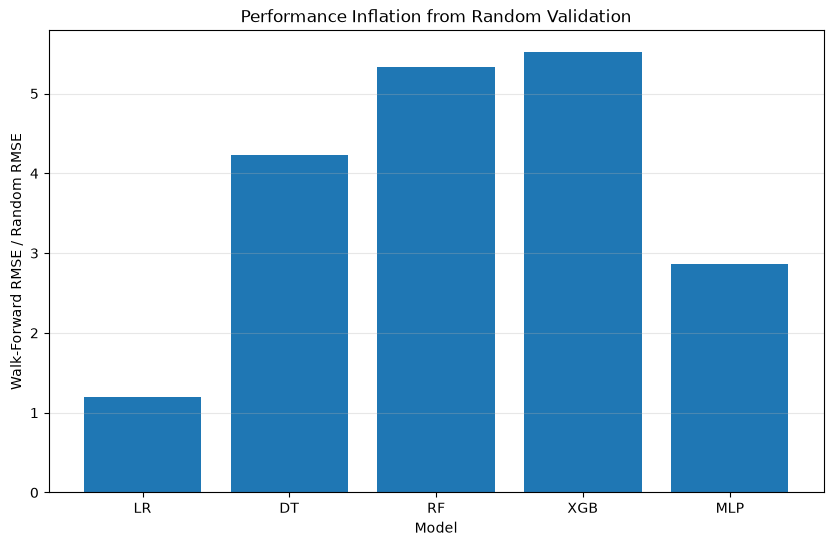

In [49]:
inflation = [
    mean_rmse_lr_wf / rmse,
    mean_rmse_dt_wf / rmse_dt_random,
    mean_rmse_rf_wf / rmse_rf_random,
    mean_rmse_xgb_wf / rmse_xgb_random,
    mean_rmse_mlp_wf / rmse_mlp_random
]

plt.figure(figsize=(10,6))

plt.bar(
    [
        "LR",
        "DT",
        "RF",
        "XGB",
        "MLP"
    ],
    inflation
)

plt.ylabel("Walk-Forward RMSE / Random RMSE")
plt.xlabel("Model")
plt.title("Performance Inflation from Random Validation")

plt.grid(axis="y", alpha=0.3)

plt.show()

#### **LSTM EXPERIMENTS**

##### **Expeiriment 1 - Raw OHLCV**

In [50]:
raw_features = ["open", "high", "low", "close", "volume"]

X_raw = df[raw_features]
y_raw = df["next_day_close"]

split_index = int(len(df)*0.8)

X_raw_train = X_raw.iloc[:split_index]
X_raw_test = X_raw.iloc[split_index:]

y_raw_train = y_raw.iloc[:split_index]
y_raw_test = y_raw.iloc[split_index:]

print(X_raw_train.shape)
print(X_raw_test.shape)
print(y_raw_train.shape)
print(y_raw_test.shape)


(2012, 5)
(504, 5)
(2012,)
(504,)


In [82]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

X_raw_train_scaled = scaler.fit_transform(X_raw_train)
X_raw_test_scaled = scaler.transform(X_raw_test)

# Creating LSTM Sequences
def create_lstm_sequences(X, y, lookback=10):
    X_sequences = []
    y_sequences = []
    
    for i in range(lookback, len(X)):
        X_sequences.append(X[i-lookback:i])
        y_sequences.append(y.iloc[i])
    
    return np.array(X_sequences), np.array(y_sequences)

lookback = 10

X_lstm_train, y_lstm_train = create_lstm_sequences(
    X_raw_train_scaled,
    y_raw_train,
    lookback
)

X_lstm_test, y_lstm_test = create_lstm_sequences(
    X_raw_test_scaled,
    y_raw_test,
    lookback
)

print(X_lstm_train.shape)
print(y_lstm_train.shape)
print(X_lstm_test.shape)
print(y_lstm_test.shape)


(2002, 10, 5)
(2002,)
(494, 10, 5)
(494,)


In [52]:
import tensorflow as tf
print(tf.__version__)


2.21.0


In [86]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import random

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)
tf.config.experimental.enable_op_determinism()

model = Sequential([
    Input(shape=(10,5)),
    LSTM(units=50),
    Dense(1)
])

model.compile(optimizer="adam",
              loss="mse")

early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 10,
    restore_best_weights = True
)

history = model.fit(
    X_lstm_train, y_lstm_train, epochs = 300, batch_size = 32, validation_data = (X_lstm_test, y_lstm_test),
    callbacks = [early_stop],
    verbose = 1
)

lstm_predictions = model.predict(X_lstm_test)
lstm_predictions = lstm_predictions.flatten()

Epoch 1/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 96405.4922 - val_loss: 113613.9141
Epoch 2/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 91936.6094 - val_loss: 109690.3125
Epoch 3/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 89572.0234 - val_loss: 107236.1016
Epoch 4/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 87796.9688 - val_loss: 105016.3438
Epoch 5/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 86121.8984 - val_loss: 102707.2344
Epoch 6/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 84389.8359 - val_loss: 100583.0469
Epoch 7/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 82832.9922 - val_loss: 98570.6797
Epoch 8/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 81343.6484 - val_loss: 96624.7891
Epoch 9/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 79904.1406 - val_loss: 94732.4375
Epoch 10/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 78507.1172 - val_loss: 92886.6094
Epoch 11/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step 

In [87]:
#Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lstm_time = mean_absolute_error(y_lstm_test, lstm_predictions)
mse_lstm_time = mean_squared_error(y_lstm_test, lstm_predictions)
rmse_lstm_time = mse_lstm_time **0.5
r2_lstm_time = r2_score(y_lstm_test, lstm_predictions)

print("MAE: ", mae_lstm_time)
print("RMSE: ", rmse_lstm_time)
print("R2: ", r2_lstm_time)


MAE:  13.87033939053209
RMSE:  19.936234527144002
R2:  0.9508822278159894


##### **Experiment 2 - All Engineered Features**

In [88]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_time)
X_test_scaled = scaler.transform(X_test_time)

# # Creating LSTM Sequences
# def create_lstm_sequences(X, y, lookback=10):
#     X_sequences = []
#     y_sequences = []
    
#     for i in range(lookback, len(X)):
#         X_sequences.append(X[i-lookback:i])
#         y_sequences.append(y.iloc[i])
    
#     return np.array(X_sequences), np.array(y_sequences)

lookback = 10

X_lstm_train, y_lstm_train = create_lstm_sequences(
    X_train_scaled,
    y_train_time,
    lookback
)

X_lstm_test, y_lstm_test = create_lstm_sequences(
    X_test_scaled,
    y_test_time,
    lookback
)

print(X_lstm_train.shape)
print(y_lstm_train.shape)
print(X_lstm_test.shape)
print(y_lstm_test.shape)


(2002, 10, 18)
(2002,)
(494, 10, 18)
(494,)


In [91]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)
tf.config.experimental.enable_op_determinism()

model = Sequential([
    Input(shape=(10,18)),
    LSTM(units=50),
    Dense(1)
])

model.compile(optimizer="adam",
              loss="mse")

early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 10,
    restore_best_weights = True
)

history = model.fit(
    X_lstm_train, y_lstm_train, epochs = 300, batch_size = 32, validation_data = (X_lstm_test, y_lstm_test),
    callbacks = [early_stop],
    verbose = 1
)

lstm_predictions_eng = model.predict(X_lstm_test)
lstm_predictions_eng = lstm_predictions_eng.flatten()

Epoch 1/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 96241.8438 - val_loss: 113270.9297
Epoch 2/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 92065.1406 - val_loss: 109443.1484
Epoch 3/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 89305.5000 - val_loss: 106766.4531
Epoch 4/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 87380.8047 - val_loss: 104413.3984
Epoch 5/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 85669.4141 - val_loss: 102243.1250
Epoch 6/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 84064.1562 - val_loss: 100172.4609
Epoch 7/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 82529.0078 - val_loss: 98175.0859
Epoch 8/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 81048.9609 - val_loss: 96237.1172
Epoch 9/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 79615.4688 - val_loss: 94350.1641
Epoch 10/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 78223.0859 - val_loss: 92508.6094
Epoch 11/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 76

In [90]:
#Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lstm_eng_time = mean_absolute_error(y_lstm_test, lstm_predictions_eng)
rmse_lstm_eng_time = mean_squared_error(y_lstm_test, lstm_predictions_eng) ** 0.5
r2_lstm_eng_time = r2_score(y_lstm_test, lstm_predictions_eng)

print("MAE: ", mae_lstm_eng_time)
print("RMSE: ", rmse_lstm_eng_time)
print("R2: ", r2_lstm_eng_time)

MAE:  29.208985546948636
RMSE:  41.355130551043835
R2:  0.7886456528839854


In [92]:
# Justified Capacity Test

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)
tf.config.experimental.enable_op_determinism()

model = Sequential([
    Input(shape=(10,18)),
    LSTM(units=100),
    Dense(1)
])

model.compile(optimizer="adam",
              loss="mse")

early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 10,
    restore_best_weights = True
)

history = model.fit(
    X_lstm_train, y_lstm_train, epochs = 300, batch_size = 32, validation_data = (X_lstm_test, y_lstm_test),
    callbacks = [early_stop],
    verbose = 1
)

lstm_predictions_eng = model.predict(X_lstm_test)
lstm_predictions_eng = lstm_predictions_eng.flatten()

Epoch 1/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 94086.9766 - val_loss: 108740.4375
Epoch 2/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 87514.9219 - val_loss: 103096.0391
Epoch 3/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 83878.3594 - val_loss: 98855.5312
Epoch 4/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 80742.7266 - val_loss: 94795.8750
Epoch 5/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 77790.1094 - val_loss: 90894.9297
Epoch 6/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 75018.8672 - val_loss: 87321.3594
Epoch 7/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 72457.3750 - val_loss: 83930.2891
Epoch 8/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 70037.1562 - val_loss: 80691.4609
Epoch 9/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 67740.8516 - val_loss: 77589.0078
Epoch 10/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 65557.8984 - val_loss: 74612.3906
Epoch 11/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 63480.

In [93]:
#Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lstm_eng_time = mean_absolute_error(y_lstm_test, lstm_predictions_eng)
rmse_lstm_eng_time = mean_squared_error(y_lstm_test, lstm_predictions_eng) ** 0.5
r2_lstm_eng_time = r2_score(y_lstm_test, lstm_predictions_eng)

print("MAE: ", mae_lstm_eng_time)
print("RMSE: ", rmse_lstm_eng_time)
print("R2: ", r2_lstm_eng_time)

MAE:  21.39249220659239
RMSE:  29.398601290546946
R2:  0.8931915213698854


###### *The engineered-feature LSTM was partly underpowered with 50 units, because increasing capacity to 100 units improved RMSE from 41.36 to 29.40.*

###### *LSTM Raw OHLCV, 50 units: RMSE 19.94*
###### *LSTM Engineered, 50 units: RMSE 41.36*
###### *LSTM Engineered, 100 units: RMSE 29.40*

###### *But it still did not beat the raw OHLCV LSTM.*

###### *That suggests the issue is not only capacity. The engineered features may add redundancy/noise for the LSTM.*